# Commodity Prices Query

Queries six commodity futures through the `macro_data` package — three metals (`gold_usd` `GC=F`, `silver_usd` `SI=F`, `copper_usd` `HG=F`) and three energy contracts (`brent_oil` `BZ=F`, `wti_oil` `CL=F`, `natural_gas` `NG=F`) — then compares all six on a single normalized chart.

These six commodities are quoted in different units (USD/oz, USD/lb, USD/MMBtu, USD/bbl) and span very different magnitudes (gold in the thousands, silver in the tens, copper and natural gas in the single digits), so a plain overlay chart of raw prices wouldn't be readable; each series is instead indexed to 100 at its first common date, the same technique used in `data_gathering_demo.ipynb`'s "Comparing multiple series" section.

This is a simple fetch → load → plot notebook (same style as `oil_prices_query.ipynb`) — no trend analysis (moving averages, volatility, 52-week range), no spread/ratio calculations, and no OHLCV bars. It complements rather than duplicates `oil_prices_query.ipynb`, which covers only Brent vs. WTI in native USD/bbl units without normalization.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

from macro_data import update, load

pd.set_option("display.max_rows", 20)
%matplotlib inline

yahoo_status = update("yahoo")  # refreshes all yahoo series, including all 6 commodities below
print("yahoo:", yahoo_status)

yahoo: {'usd_thb': 'up-to-date', 'eur_usd': 'up-to-date', 'gold_usd': 'up-to-date', 'brent_oil': 'up-to-date', 'wti_oil': 'up-to-date', 'silver_usd': 'up-to-date', 'copper_usd': 'up-to-date', 'natural_gas': 'up-to-date', 'sp500': 'up-to-date', 'set_index': 'up-to-date', 'usd_dxy': 'up-to-date', 'eur_thb': 'up-to-date', 'jpy_thb': 'up-to-date', 'gbp_thb': 'up-to-date', 'us_3m_yield': 'up-to-date', 'us_5y_yield': 'up-to-date', 'us_10y_yield': 'up-to-date', 'us_30y_yield': 'up-to-date'}


## Load & recent values

In [2]:
labels = {
    "gold_usd": "Gold (GC=F)",
    "silver_usd": "Silver (SI=F)",
    "copper_usd": "Copper (HG=F)",
    "brent_oil": "Brent crude (BZ=F)",
    "wti_oil": "WTI crude (CL=F)",
    "natural_gas": "Natural gas (NG=F)",
}
commodities = {sid: load(sid) for sid in labels}

for sid, label in labels.items():
    print(f"{label}:")
    display(commodities[sid].tail())

Gold (GC=F):


,value
date,
2026-07-08,4070.899902
2026-07-09,4130.600098
2026-07-10,4122.500000
2026-07-13,3997.000000
2026-07-15,4042.300049


Silver (SI=F):


,value
date,
2026-07-09,60.377998
2026-07-10,59.808998
2026-07-13,57.633999
2026-07-14,58.771999
2026-07-15,58.360001


Copper (HG=F):


...

,value
date,
2026-07-08,78.019997
2026-07-09,76.300003
2026-07-10,76.260002
2026-07-13,83.300003
2026-07-15,85.870003


WTI crude (CL=F):


,value
date,
2026-07-09,72.080002
2026-07-10,71.410004
2026-07-13,78.139999
2026-07-14,79.339996
2026-07-15,79.839996


Natural gas (NG=F):


,value
date,
2026-07-09,3.012
2026-07-10,2.940
2026-07-13,2.897
2026-07-14,2.904
2026-07-15,2.922


## Normalized comparison

Gold, silver, and copper are quoted per troy ounce or pound; Brent, WTI, and natural gas per barrel or MMBtu — and price levels range from single digits (natural gas, copper) up to the thousands (gold). Overlaying raw values would flatten every series except gold into an unreadable line along the bottom of the chart, so — following the same approach as `data_gathering_demo.ipynb`'s "Comparing multiple series" section — each series is indexed to 100 at its first common date before plotting.

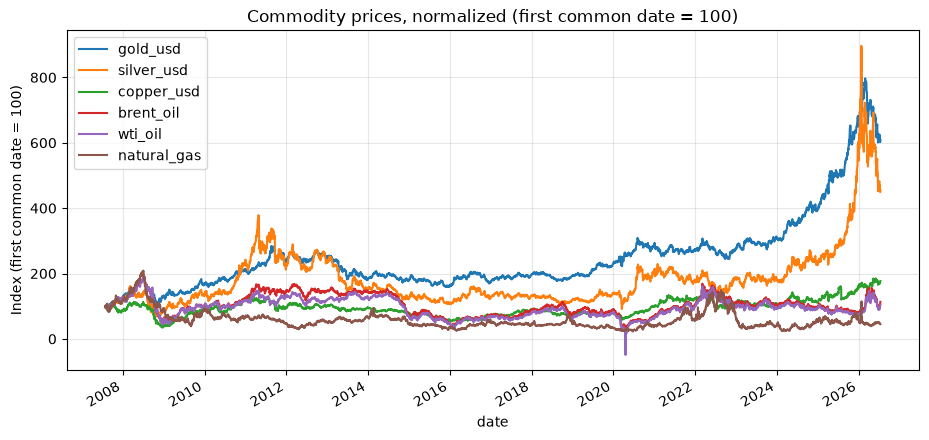

In [3]:
combined = pd.DataFrame({sid: commodities[sid]["value"] for sid in labels}).dropna()
normalized = combined / combined.iloc[0] * 100

fig, ax = plt.subplots(figsize=(11, 5))
normalized.plot(ax=ax, title="Commodity prices, normalized (first common date = 100)")
ax.set_ylabel("Index (first common date = 100)")
ax.grid(alpha=0.3)
plt.show()